# How to retrieve AlphaEarth embeddings:

In [1]:
import xarray as xr
import s3fs

# should be 10mx10m

ds = xr.open_zarr("s3://us-west-2.opendata.source.coop/tge-labs/aef-mosaic/", consolidated=False, storage_options={"anon": True}) 
ds

# The embeddings are originally 32-bit floats natively trained to sit on a 64-dimensional unit hypersphere ($S^{63}$). 
# For the public release, they quantized them to signed 8-bit integers
# The range of the raw output you are seeing is -127 to 127.

/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/zarr/core/group.py:3559: ZarrUserWarning: Object at README.md is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/zarr/core/group.py:3559: ZarrUserWarning: Object at .checkpoint is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


<xarray.Dataset> Size: 4PB
Dimensions:     (time: 9, band: 64, y: 1859584, x: 4009984)
Coordinates:
  * time        (time) int32 36B 2017 2018 2019 2020 2021 2022 2023 2024 2025
  * band        (band) StringDType() 1kB 'A00' 'A01' 'A02' ... 'A61' 'A62' 'A63'
  * y           (y) float64 15MB 83.69 83.69 83.69 ... -83.36 -83.36 -83.36
  * x           (x) float64 32MB -180.0 -180.0 -180.0 ... 180.2 180.2 180.2
Data variables:
    embeddings  (time, band, y, x) int8 4PB ...
Attributes: (12/15)
    proj:code:               EPSG:4326
    spatial:dimensions:      ['y', 'x']
    spatial:transform:       [8.983111749910169e-05, 0.0, -180.0, 0.0, -8.983...
    spatial:transform_type:  affine
    spatial:bbox:            [-180.0, -83.36280346631479, 180.2213438735178, ...
    spatial:shape:           [1859584, 4009984]
    ...                      ...
    geoemb:model:            https://developers.google.com/earth-engine/datas...
    geoemb:source_data:      https://source.coop/tge-labs/aef/v1/annual/
    geoemb:data_type:        int8
    geoemb:gsd:              8.983111749910169e-05
    geoemb:quantization:     {'method': 'signed_square', 'original_dtype': 'f...
    zarr_conventions:        [{'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f'...

In [2]:
print("AEF Longitude range:", ds.x.min().values, "to", ds.x.max().values)
print("AEF Latitude range:", ds.y.min().values, "to", ds.y.max().values)

AEF Longitude range: -179.99995508444124 to 180.22129895795905
AEF Latitude range: -83.36275855075603 to 83.68566042157599


In [2]:
# Extract the 64-band embedding for a specific time and location
point_embedding = ds.embeddings.sel(
    time=2023,
    x=-93.6, # Longitude
    y=41.5,  # Latitude
    method="nearest"
)
point_embedding

<xarray.DataArray 'embeddings' (band: 64)> Size: 64B
[64 values with dtype=int8]
Coordinates:
  * band     (band) StringDType() 1kB 'A00' 'A01' 'A02' ... 'A61' 'A62' 'A63'
    x        float64 8B -93.6
    y        float64 8B 41.5
    time     int32 4B 2023
Attributes:
    _zarrs:   {'description': 'This array was created with zarrs', 'repositor...

In [ ]:
import numpy as np
# should apply re-quantization scheme before downstream analysis using the embeddings
# code from original paper
def dequantize_embedding(y, power=2.0, scale=127.5):
    """Restores the int8 embedding back to its original float32 representation."""
    rescaled = y.astype(np.float32) / scale
    return (np.abs(rescaled) ** power) * np.sign(rescaled)


# Visualize embeddings using PCA

In [ ]:
# sample all lat (degrees north) [-90, 90] lon (degrees east) [-180, 180] at 1 degree resolution (make it higher later)
# filter to land mass only (optional)
# plot it over a map
import numpy as np
from global_land_mask import globe  # treats lakes as on-land

x = np.linspace(-180, 180, 361)  # 1 degree resolution
y = np.linspace(-80, 80, 161) # AEF only covers up to like 83 degrees north/south 
lon_grid, lat_grid = np.meshgrid(x, y)
coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)


land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order
land_coords = coords[land_mask]
land_coords.shape

YEAR = 2021  # example year
years = np.array([YEAR] * land_coords.shape[0])


In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

mkdir -p failed for path /afs/csail.mit.edu/u/s/sazhang/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-8tn42kst because there was an issue with the default path (/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
# Get embeddings (if not already saved)
target_times = xr.DataArray(years, dims="points")
target_xs = xr.DataArray(land_coords[:, 0], dims="points")  # longitude
target_ys = xr.DataArray(land_coords[:, 1], dims="points")  # latitude

embeddings = ds.embeddings.sel(
    time=target_times,
    x=target_xs,
    y=target_ys,
    method="nearest"
)
embeddings = dequantize_embedding(embeddings.values)
np.save("outputs/alphaearth_embeddings_global_land_mass_x_-180_180_y_-80_80_resolution_half_degree.npy", embeddings)
print("embeddings shape:", embeddings.shape)    

# took 15 mins to run for 21677 points 


In [ ]:
embeddings = np.load("outputs/alphaearth_embeddings_global_land_mass_x_-180_180_y_-80_80_resolution_half_degree.npy")

# mask out the lowest latitudes that are out of bounds for AE
lat_mask = land_coords[:, 1] >= -72 # -70 or -72 is decent visualization
filtered_land_coords = land_coords[lat_mask]
filtered_embs = embeddings[lat_mask]

# Run PCA to extract the top 3 components
pca = PCA(n_components=3)
pca_embs = pca.fit_transform(filtered_embs)

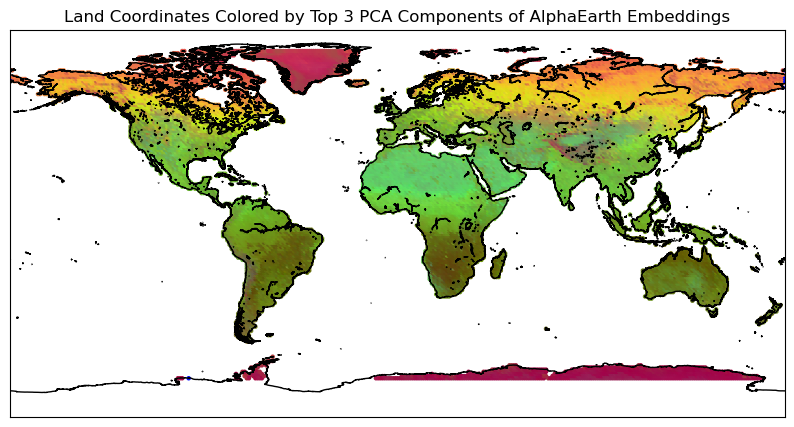

In [ ]:
# Normalize the 3 PCA components to [0, 1] for RGB colors
colors = pca_embs - pca_embs.min(axis=0, keepdims=True)
colors = colors / (colors.max(axis=0, keepdims=True) + 1e-8)

# Plot over a map
fig, ax = plt.subplots(1, figsize=(10, 6))

m = Basemap(projection='cyl', resolution='i', ax=ax)
m.drawcoastlines()

# Scatter using the coordinates and the PCA RGB colors
ax.scatter(filtered_land_coords[:, 0], filtered_land_coords[:, 1], c=colors, s=5)
ax.set_title('Land Coordinates Colored by Top 3 PCA Components of AlphaEarth Embeddings')

plt.show()

N= 2735 for ocean points


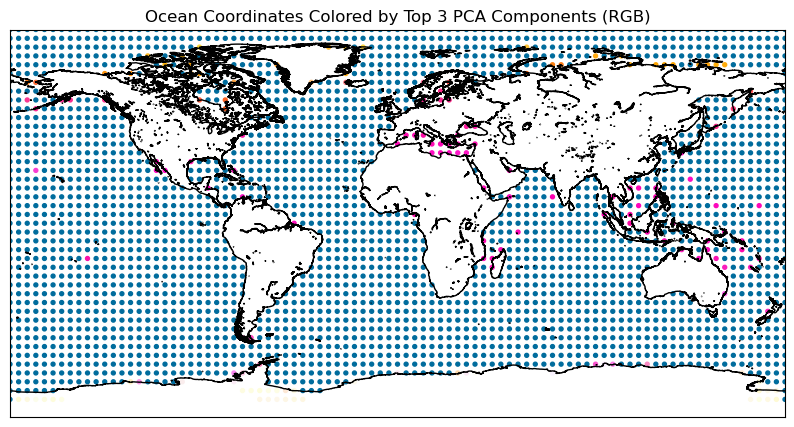

In [ ]:
# now do ocean at low res

x = np.linspace(-180, 180, 91)  # 1 degree resolution
y = np.linspace(-90, 90, 45) 
lon_grid, lat_grid = np.meshgrid(x, y)
coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)


land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order
ocean_coords = coords[~land_mask]

YEAR = 2023  # example year
years = np.array([YEAR] * ocean_coords.shape[0])
print("N=", years.shape[0], "for ocean points")


# Get embeddings in batches
target_times = xr.DataArray(years, dims="points")
target_xs = xr.DataArray(ocean_coords[:, 0], dims="points")  # longitude
target_ys = xr.DataArray(ocean_coords[:, 1], dims="points")  # latitude

embeddings = ds.embeddings.sel(
    time=target_times,
    x=target_xs,
    y=target_ys,
    method="nearest"
)
embeddings = dequantize_embedding(embeddings.values)

# Run PCA to extract the top 3 components
pca = PCA(n_components=3)
pca_embs = pca.fit_transform(embeddings)

# Normalize the 3 PCA components to [0, 1] for RGB colors
colors = pca_embs - pca_embs.min(axis=0, keepdims=True)
colors = colors / (colors.max(axis=0, keepdims=True) + 1e-8)

# Plot over a map
fig, ax = plt.subplots(1, figsize=(10, 6))

m = Basemap(projection='cyl', resolution='i', ax=ax)
m.drawcoastlines()

# Scatter using the coordinates and the PCA RGB colors
ax.scatter(ocean_coords[:, 0], ocean_coords[:, 1], c=colors, s=8)
ax.set_title('Ocean Coordinates Colored by Top 3 PCA Components (RGB)')

plt.show()


pretty unremarkable

# Dim Reduction of Regions: tSNE and UMAP

In [25]:
import pandas as pd

rainshift_df = pd.read_csv("/home/sazhang/downscaling_transferability_with_geographic_features/rainshift_regions_info.csv")

resolution = 0.5
regions_coords = {}
for idx, row in rainshift_df.iterrows():
    region, lat_min, lat_max, lon_min, lon_max = row['region'], row['lat_min'], row['lat_max'], row['lon_min'], row['lon_max']
    x = np.linspace(lon_min, lon_max, int((lon_max - lon_min) / resolution) + 1)  # 1 degree resolution
    y = np.linspace(lat_min, lat_max, int((lat_max - lat_min) / resolution) + 1)
    lon_grid, lat_grid = np.meshgrid(x, y)
    coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)

    regions_coords[region] = coords

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [26]:

regions_embeddings = {}
for region, coords in regions_coords.items():
    print("Getting embeddings from region", region)

    target_times = xr.DataArray(np.array([YEAR]*len(coords)), dims="points")
    target_xs = xr.DataArray(coords[:, 0], dims="points")  # longitude
    target_ys = xr.DataArray(coords[:, 1], dims="points")  # latitude

    embeddings = ds.embeddings.sel(
        time=target_times,
        x=target_xs,
        y=target_ys,
        method="nearest"
    )
    embeddings = dequantize_embedding(embeddings.values)
    regions_embeddings[region] = embeddings



Getting embeddings from region africa-south
Getting embeddings from region amazon-basin
Getting embeddings from region arabian-peninsula
Getting embeddings from region australasia-east
Getting embeddings from region blacksea
Getting embeddings from region cape-horn
Getting embeddings from region caribbean
Getting embeddings from region east-asia-north-east
Getting embeddings from region east-asia-south
Getting embeddings from region europe_west
Getting embeddings from region horn-of-africa
Getting embeddings from region melanesia
Getting embeddings from region northamerica-east
Getting embeddings from region northamerica-west
Getting embeddings from region southamerica-east
Getting embeddings from region southeastasia-west
Getting embeddings from region tibetan-plateau
Getting embeddings from region west-africa


In [ ]:
import os
import numpy as np

save_dir = "rainshift_aef_features"
os.makedirs(save_dir, exist_ok=True)

# Save to .npz files
for region in regions_coords.keys():
    coords_file = os.path.join(save_dir, f"{region}_coords.npz")
    emb_file = os.path.join(save_dir, f"{region}_embeddings_aef.npz")
    
    np.savez(coords_file, data=regions_coords[region])
    np.savez(emb_file, data=regions_embeddings[region])
    
print(f"Saved coordinates and embeddings to ./{save_dir}/")

Saved coordinates and embeddings to ./rainshift_aef_features/


In [ ]:
# Load from .npz files
loaded_regions_coords = {}
loaded_regions_embeddings = {}

# Using the regions from your dataframe
for region in rainshift_df['region']:
    coords_file = os.path.join(save_dir, f"{region}_coords.npz")
    emb_file = os.path.join(save_dir, f"{region}_embeddings_aef.npz")
    
    if os.path.exists(coords_file) and os.path.exists(emb_file):
        loaded_regions_coords[region] = np.load(coords_file)['data']
        loaded_regions_embeddings[region] = np.load(emb_file)['data']

print("Successfully loaded regions:", list(loaded_regions_coords.keys()))

Successfully loaded regions: ['africa-south', 'amazon-basin', 'arabian-peninsula', 'australasia-east', 'blacksea', 'cape-horn', 'caribbean', 'east-asia-north-east', 'east-asia-south', 'europe_west', 'horn-of-africa', 'melanesia', 'northamerica-east', 'northamerica-west', 'southamerica-east', 'southeastasia-west', 'tibetan-plateau', 'west-africa']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap 

# Combine all embeddings and track their corresponding region labels
all_embs_list = []
labels_list = []
land_masks_list = []

for region, embs in loaded_regions_embeddings.items():
    all_embs_list.append(embs)
    labels_list.extend([region] * len(embs))

    coords = loaded_regions_coords[region]
    land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order
    land_masks_list.append(land_mask)

combined_embeddings = np.concatenate(all_embs_list, axis=0)
combined_land_mask = np.concatenate(land_masks_list, axis=0)
labels_array = np.array(labels_list)
masked_labels_array = labels_array[combined_land_mask]

unique_regions = list(loaded_regions_embeddings.keys())

# 1. Compute t-SNE (2 dimensions)
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
tsne_embs = tsne.fit_transform(combined_embeddings)

# 2. Compute UMAP (2 dimensions), applied only to land
print("Computing UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embs = reducer.fit_transform(combined_embeddings[combined_land_mask])



Computing t-SNE...
Computing UMAP...


/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


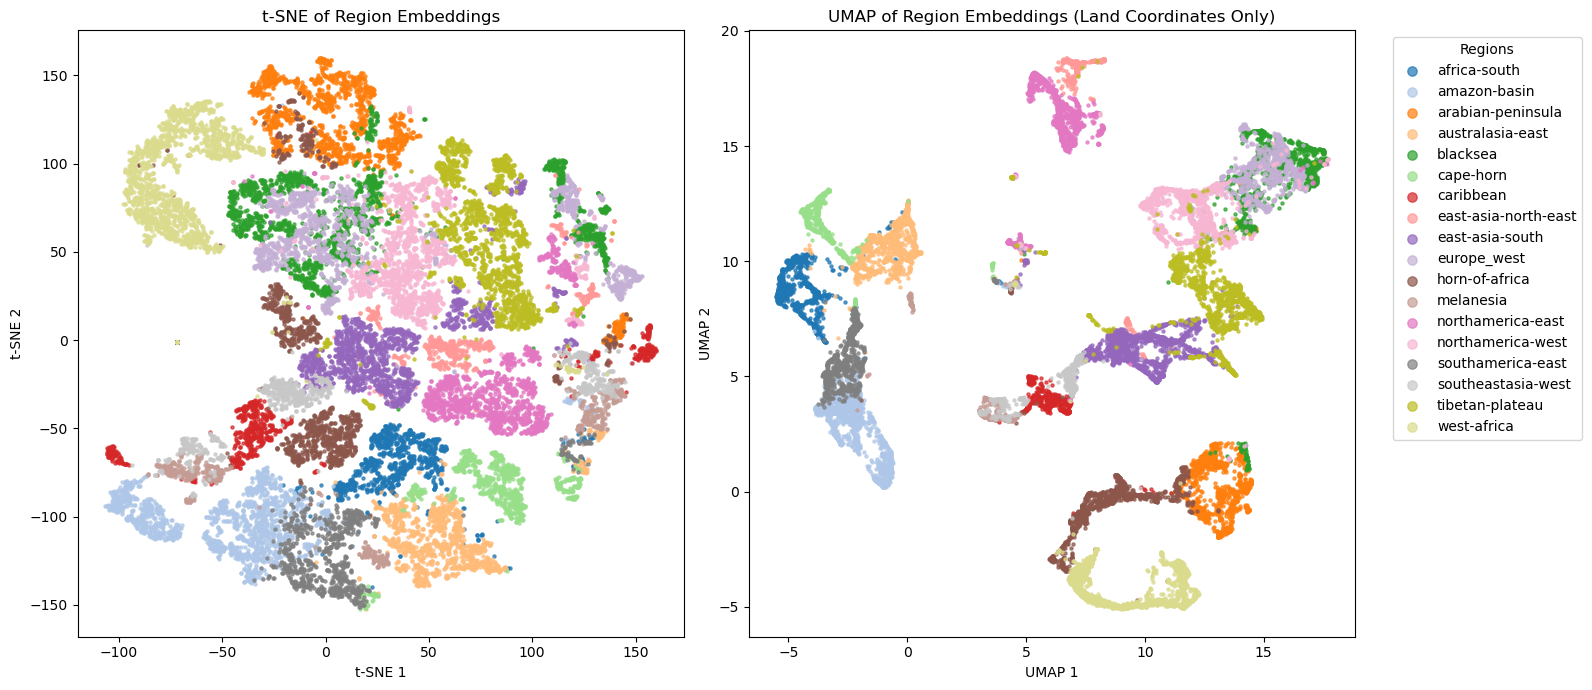

In [ ]:
# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    idx = labels_array == region
    masked_idx = masked_labels_array == region
    color = cmap(i % 20)
    
    # Scatter for t-SNE
    axes[0].scatter(tsne_embs[idx, 0], tsne_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)
    # Scatter for UMAP
    axes[1].scatter(umap_embs[masked_idx, 0], umap_embs[masked_idx, 1], s=5, c=[color], label=region, alpha=0.7)

axes[0].set_title('t-SNE of Region Embeddings')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

axes[1].set_title('UMAP of Region Embeddings (Land Coordinates Only)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# Add legend outside the plots
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/aef_embeddings_by_region_tsne_umap.png", dpi=300, bbox_inches="tight")
plt.show()

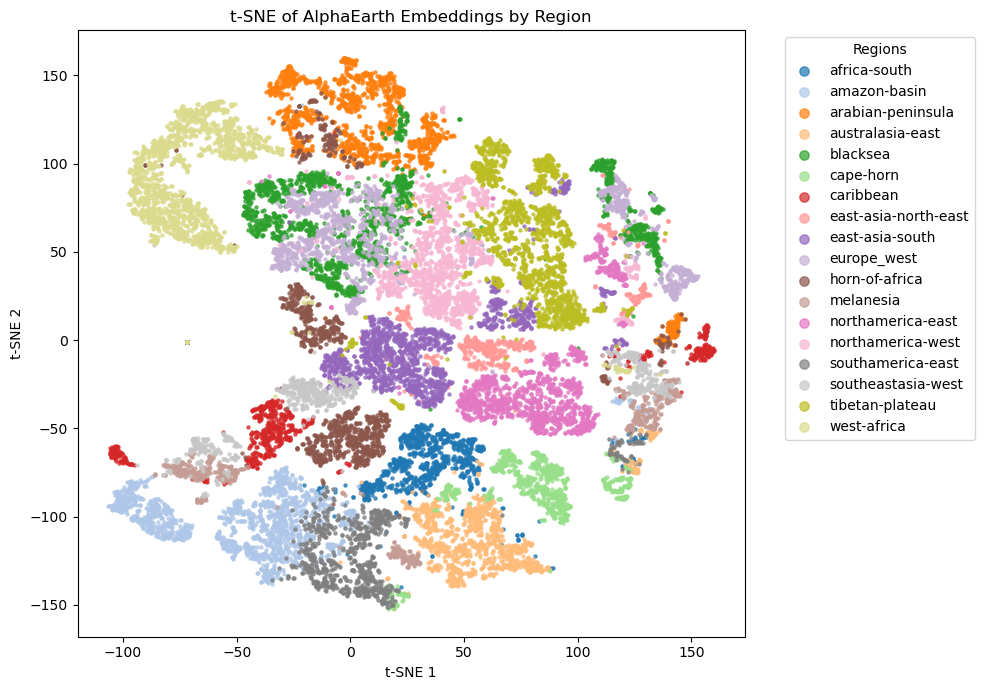

In [ ]:
# save umap and tsne plots separately

fig, ax = plt.subplots(1, figsize=(10, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    idx = labels_array == region
    color = cmap(i % 20)
    
    # Scatter for t-SNE
    ax.scatter(tsne_embs[idx, 0], tsne_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)

ax.set_title('t-SNE of AlphaEarth Embeddings by Region')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')


# Add legend outside the plots
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/aef_embeddings_by_region_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

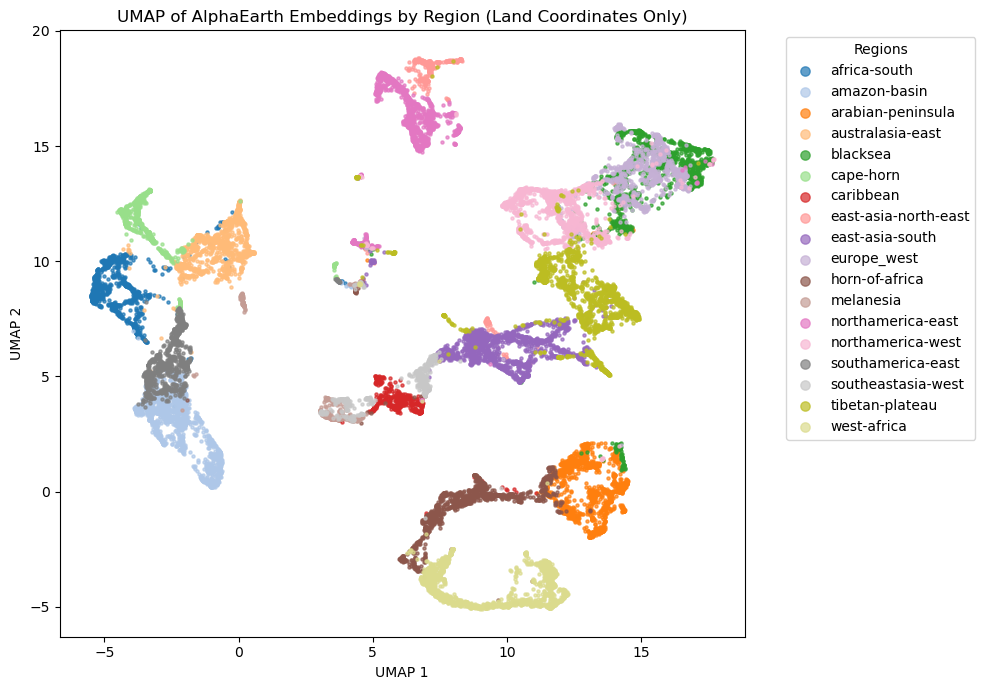

In [ ]:
# save umap and tsne plots separately
fig, ax = plt.subplots(1, figsize=(10, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    # idx = labels_array == region
    masked_idx = masked_labels_array == region
    color = cmap(i % 20)
    
    # Scatter for UMAP
    ax.scatter(umap_embs[masked_idx, 0], umap_embs[masked_idx, 1], s=5, c=[color], label=region, alpha=0.7)

ax.set_title('UMAP of AlphaEarth Embeddings by Region (Land Coordinates Only)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# Add legend outside the plots
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/aef_embeddings_by_region_umap.png", dpi=300, bbox_inches="tight")
plt.show()

Land embeddings shape: (393, 64)
Ocean embeddings shape: (1288, 64)


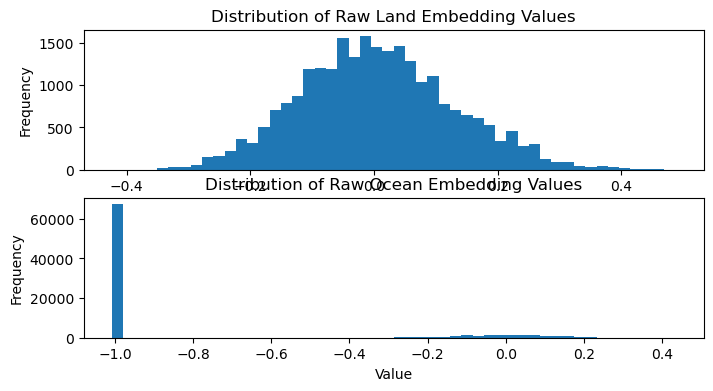

Percentage of absolute zeros in ocean points: 0.0024262422360248445
Percentage of NaNs in ocean points: 0.0


In [37]:
# Check ocean embeddings distribution
fig, axes = plt.subplots(2, figsize=(8, 4))

# Using the `ocean_coords` and `years` defined previously
coords = loaded_regions_coords["melanesia"]
embeddings = loaded_regions_embeddings["melanesia"]

land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order

land_embeddings = embeddings[land_mask]
ocean_embeddings = embeddings[~land_mask]
print("Land embeddings shape:", land_embeddings.shape)
print("Ocean embeddings shape:", ocean_embeddings.shape)

axes[0].hist(land_embeddings.flatten(), bins=50)
axes[0].set_title("Distribution of Raw Land Embedding Values")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(ocean_embeddings.flatten(), bins=50)
axes[1].set_title("Distribution of Raw Ocean Embedding Values")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")
plt.show()

print("Percentage of absolute zeros in ocean points:", np.mean(ocean_embeddings == 0) * 100)
print("Percentage of NaNs in ocean points:", np.mean(np.isnan(ocean_embeddings)) * 100)

Ocean embeddings receive a dummy value?